In [1]:
import sys
from pathlib import Path
# import us_stock_valuation_preprocessing as stock_prep
from DATA.stock_invest_function import *

def find_data_folder():
    """DATA 폴더 찾기"""
    current = Path.cwd()

    # 상위 5단계까지 검색
    for i in range(5):
        data_path = current / "DATA"
        if data_path.exists():
            target_files = [
                data_path / "stock_invest_function.py",
                data_path / "us_stock_valuation_preprocessing.py"
            ]
            if all(f.exists() for f in target_files):
                return data_path
        current = current.parent
    return None

def fix_and_import_modules():
    """모듈을 수정해서 import"""
    data_path = find_data_folder()
    if not data_path:
        print("DATA 폴더를 찾을 수 없습니다")
        return None, None

    sys.path.insert(0, str(data_path))
    print(f"DATA 폴더 발견: {data_path}")

    # stock_invest_function은 정상 import
    try:
        import stock_invest_function as stock_func
        print("stock_invest_function import 성공!")
    except Exception as e:
        print(f"stock_invest_function import 실패: {e}")
        stock_func = None

    # us_stock_valuation_preprocessing은 파일을 읽어서 수정 후 실행
    try:
        preprocessing_file = data_path / "us_stock_valuation_preprocessing.py"

        # 파일 내용 읽기
        with open(preprocessing_file, 'r', encoding='utf-8') as f:
            content = f.read()

        # 문제가 되는 부분을 찾아서 수정
        # "from stock_invest_function import *"를 모듈 최상위로 이동
        lines = content.split('\n')

        # import * 구문을 찾아서 제거하고 최상위에 추가
        fixed_lines = []
        import_lines = []
        inside_function = False

        for line in lines:
            # 함수 시작 감지
            if line.strip().startswith('def '):
                inside_function = True

            # import * 구문 처리
            if 'from stock_invest_function import *' in line:
                if inside_function:
                    # 함수 내부에 있으면 제거
                    continue
                else:
                    # 최상위에 있으면 그대로 유지
                    import_lines.append(line)
                    continue

            fixed_lines.append(line)

        # 수정된 내용 조합
        final_content = '\n'.join(import_lines + [''] + fixed_lines)

        # 수정된 내용을 실행해서 모듈 생성
        import types
        stock_prep = types.ModuleType('us_stock_valuation_preprocessing')

        # get_db_host 함수가 필요한 경우를 위해 미리 정의
        if stock_func and hasattr(stock_func, 'get_db_host'):
            stock_prep.get_db_host = stock_func.get_db_host
        else:
            stock_prep.get_db_host = lambda: 'localhost'

        # 수정된 코드 실행
        exec(final_content, stock_prep.__dict__)

        print("us_stock_valuation_preprocessing 수정 후 import 성공!")
        return stock_func, stock_prep

    except Exception as e:
        print(f"파일 수정 중 오류: {e}")
        return stock_func, None

# 실행
stock_func, stock_prep = fix_and_import_modules()

if stock_func and stock_prep:
    print("모든 모듈이 성공적으로 로드되었습니다!")
    print("사용 가능한 함수들:")
    if hasattr(stock_prep, 'run_data_preprocessing'):
        print("- stock_prep.run_data_preprocessing()")
    if hasattr(stock_prep, 'run_simple_preprocessing'):
        print("- stock_prep.run_simple_preprocessing()")
else:
    print("모듈 로드에 실패했습니다.")

import us_stock_valuation_preprocessing_v2 as stock_prep

DATA 폴더 발견: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
stock_invest_function import 성공!
us_stock_valuation_preprocessing 수정 후 import 성공!
모든 모듈이 성공적으로 로드되었습니다!
사용 가능한 함수들:


In [2]:
from stock_invest_function import *

In [3]:
api_key = 'hT0gAk87j9xZx4PlBApvBqfVL5IahvgV'

# db_info = {
#     'host': get_db_host(),
#     'port': 3307,
#     'user': 'stox7412',
#     'password': 'Apt106503!~',
#     'database': 'investar'
# }
#
# # 1. 먼저 디버깅으로 원인 파악
# # stock_prep.debug_missing_data(result, 'AMAT', db_info)
#
# # 기본 사용 (수출 데이터 포함)
# result = stock_prep.run_enhanced_preprocessing(
#     ticker='AMAT',
#     api_key=api_key,
#     db_info=db_info,
#     hs_code='841191'  # 수출 데이터 포함 시
# )

# # 간단한 사용 (수출 데이터 제외)
# result = run_simple_enhanced_preprocessing(
#     ticker='AMAT',
#     api_key='your_api_key',
#     db_info=db_info
# )

# 단일 종목 간단 버전
# result = stock_prep.run_simple_preprocessing('AAPL', api_key)

# === 사용자 설정 ===
API_KEY = 'hT0gAk87j9xZx4PlBApvBqfVL5IahvgV'
TICKER  = "AMAT"

# DB 접속 정보 (예: investar)
db_info = {
    "user":     'stox7412',
    "password": 'Apt106503!~',
    "host":  get_db_host(),
    "port":     3306,
    "database": "investar"
}

# API 키 점검(선택)
ok, msg = stock_prep.test_api_connection(API_KEY)
print("FMP test:", ok, msg)

# 파이프라인 실행(검증 리포트 포함)
final_df, verify_report, stats = stock_prep.run_complete_preprocessing_with_verification(
    ticker=TICKER,
    api_key=API_KEY,
    db_info=db_info,
    hs_code=None,        # 필요 시 '847150' 같은 6자리 HS 코드 지정
    start_year=2013,
    verbose=True
)

# 결과 확인
print("\n[final_df.head()]")
print(final_df.head(10))

FMP test: True API connection successful
Starting simplified preprocessing for AMAT
1. Collecting FMP data with smart date conversion...


Market Cap: 100%|██████████| 1/1 [00:12<00:00, 12.87s/it]


FMP Revenue: 47 records
FMP Market: 144 records
2. Applying simple DB supplementation...
DB Revenue supplementation: {'db_records': 0, 'overwritten': 0, 'added': 0}
DB Market supplementation: {'db_records': 0, 'filled': 0, 'added': 0}
3. Merging data...
4. Applying simple forward fill...
Forward fill results: {'before_revenue_nan': 97, 'before_market_nan': 0, 'after_revenue_nan': 3, 'after_market_nan': 0, 'revenue_filled': 94, 'market_filled': 0, 'final_records': 144}
5. Calculating TTM and PSR...
7. Final data: 144 records
Final Revenue NaN: 3
Final Market NaN: 0
Simplified preprocessing completed successfully

Preprocessing Verification Report - AMAT
Status: SUCCESS
Total Records: 144
Date Range: 2013-01 to 2024-12
Final Revenue NaN: 3
Final Market NaN: 0
Duplicate Entries: 0


ValueError: not enough values to unpack (expected 3, got 2)

In [4]:
# Basic usage (quiet mode)
# result = stock_prep.run_enhanced_preprocessing('AMAT', api_key, db_info)

# With verification and detailed reporting
result, verification, stats = stock_prep.run_complete_preprocessing_with_verification(
    "AMAT", api_key, db_info, hs_code="854231", verbose=True
)

Starting comprehensive preprocessing for AMAT
1. Collecting FMP data...


Market Cap: 100%|██████████| 1/1 [00:12<00:00, 12.81s/it]


FMP Revenue: 48 records, 0 NaN
FMP Market: 144 records, 0 NaN
2. Applying comprehensive DB supplementation...
DB Revenue supplementation: {'db_records': 0, 'overwritten': 0, 'added': 0}
DB Market supplementation: {'db_records': 0, 'filled': 0, 'added': 0}

DB Supplementation - Revenue Results:
----------------------------------------
Revenue: 0 → 0 NaN (improved: 0)

DB Supplementation - Market Results:
----------------------------------------
Market Cap: 0 → 0 NaN (improved: 0)
3. Merging data...
4. Applying comprehensive forward fill...

Forward Fill Results:
----------------------------------------
Revenue: 97 → 3 NaN (improved: 94)
Market Cap: 0 → 0 NaN (improved: 0)
5. Calculating TTM and PSR...
6. Merging export data...
7. Final data: 145 records
Final Revenue NaN: 3
Final Market NaN: 0
Preprocessing completed successfully

Preprocessing Verification Report - AMAT
Status: SUCCESS
Total Records: 145
Date Range: 2013-01 to 2024-12
Revenue Improvement: -3 NaN values fixed
Market Imp

In [5]:
result

,ticker,date_month_end,market_cap_billions,revenue_billions,revenue_billion,revenue_ttm,revenue_ttm_billions,revenue_ttm_shift,PSR_ttm,hs_code_6d,expDlr,expDlr_yoy
0,AMAT,2013-01-31,15.14,1.57,1.57,1.57,1.57,NaN,NaN,None,<NA>,<NA>
1,AMAT,2013-02-28,16.08,1.57,1.57,3.14,3.14,NaN,NaN,None,<NA>,<NA>
2,AMAT,2013-03-31,15.81,1.57,1.57,4.71,4.71,1.57,10.070064,None,<NA>,<NA>
3,AMAT,2013-04-30,17.46,1.97,1.97,6.68,6.68,3.14,5.560510,None,<NA>,<NA>
4,AMAT,2013-05-31,18.29,1.97,1.97,7.08,7.08,4.71,3.883227,None,<NA>,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...
140,AMAT,2024-08-31,162.15,6.78,6.78,26.86,26.86,26.66,6.082146,None,<NA>,<NA>
141,AMAT,2024-09-30,166.09,6.78,6.78,26.99,26.99,26.73,6.213618,None,<NA>,<NA>
142,AMAT,2024-10-31,147.81,7.04,7.04,27.38,27.38,26.86,5.502978,None,<NA>,<NA>
143,AMAT,2024-11-30,142.21,7.04,7.04,27.64,27.64,26.99,5.268989,None,<NA>,<NA>


In [6]:
from sarima_forecast import sarima_forecast
from sarima_forecast import revenue_sarima_forecast_pipeline
from us_lstm_forecast import *
from us_prophet_forecast import *

In [6]:
result_data, quarterly_data, forecast_result, model_info = revenue_sarima_forecast_pipeline(
    data=result,
    revenue_col='revenue_billions',
    data_end_date='2025-08-31',
    forecast_quarters=4
)

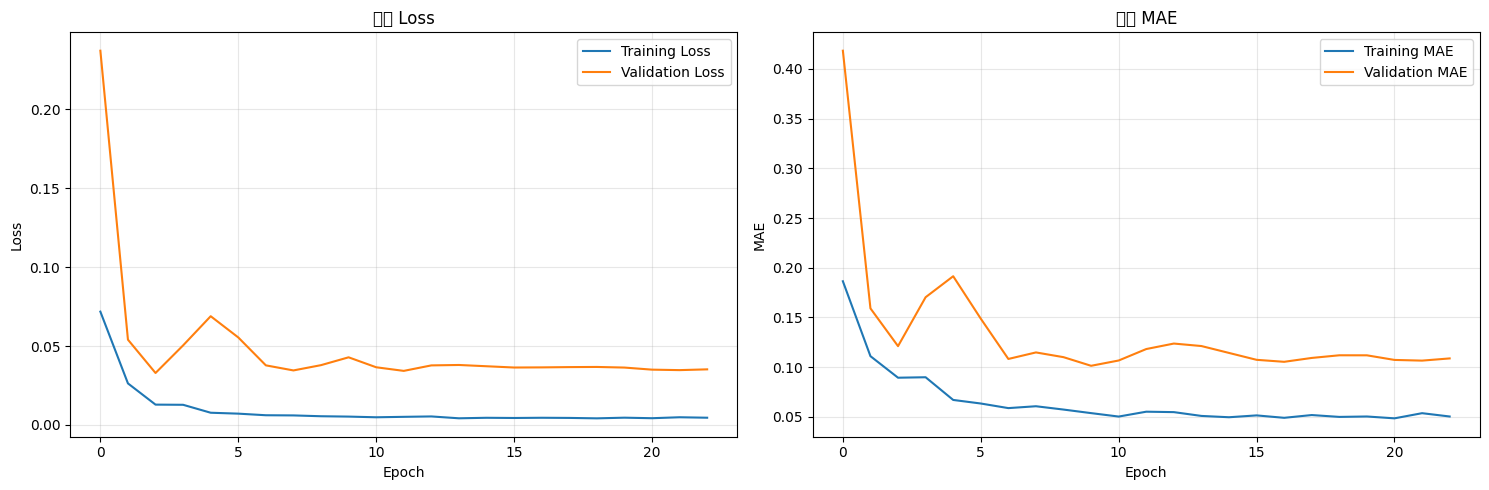

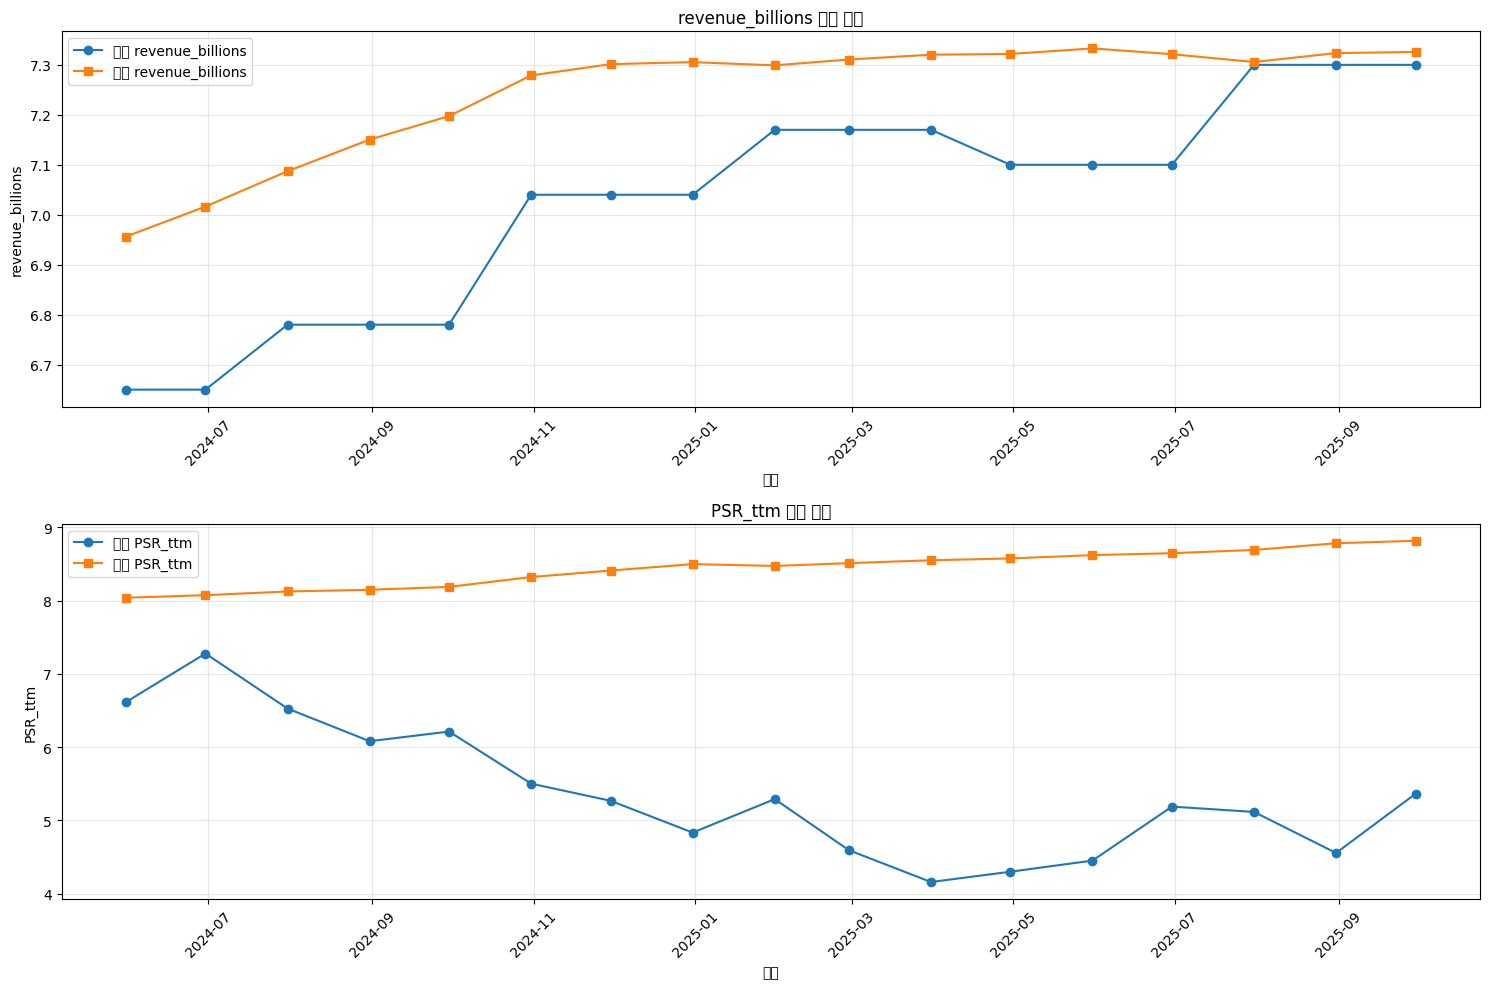

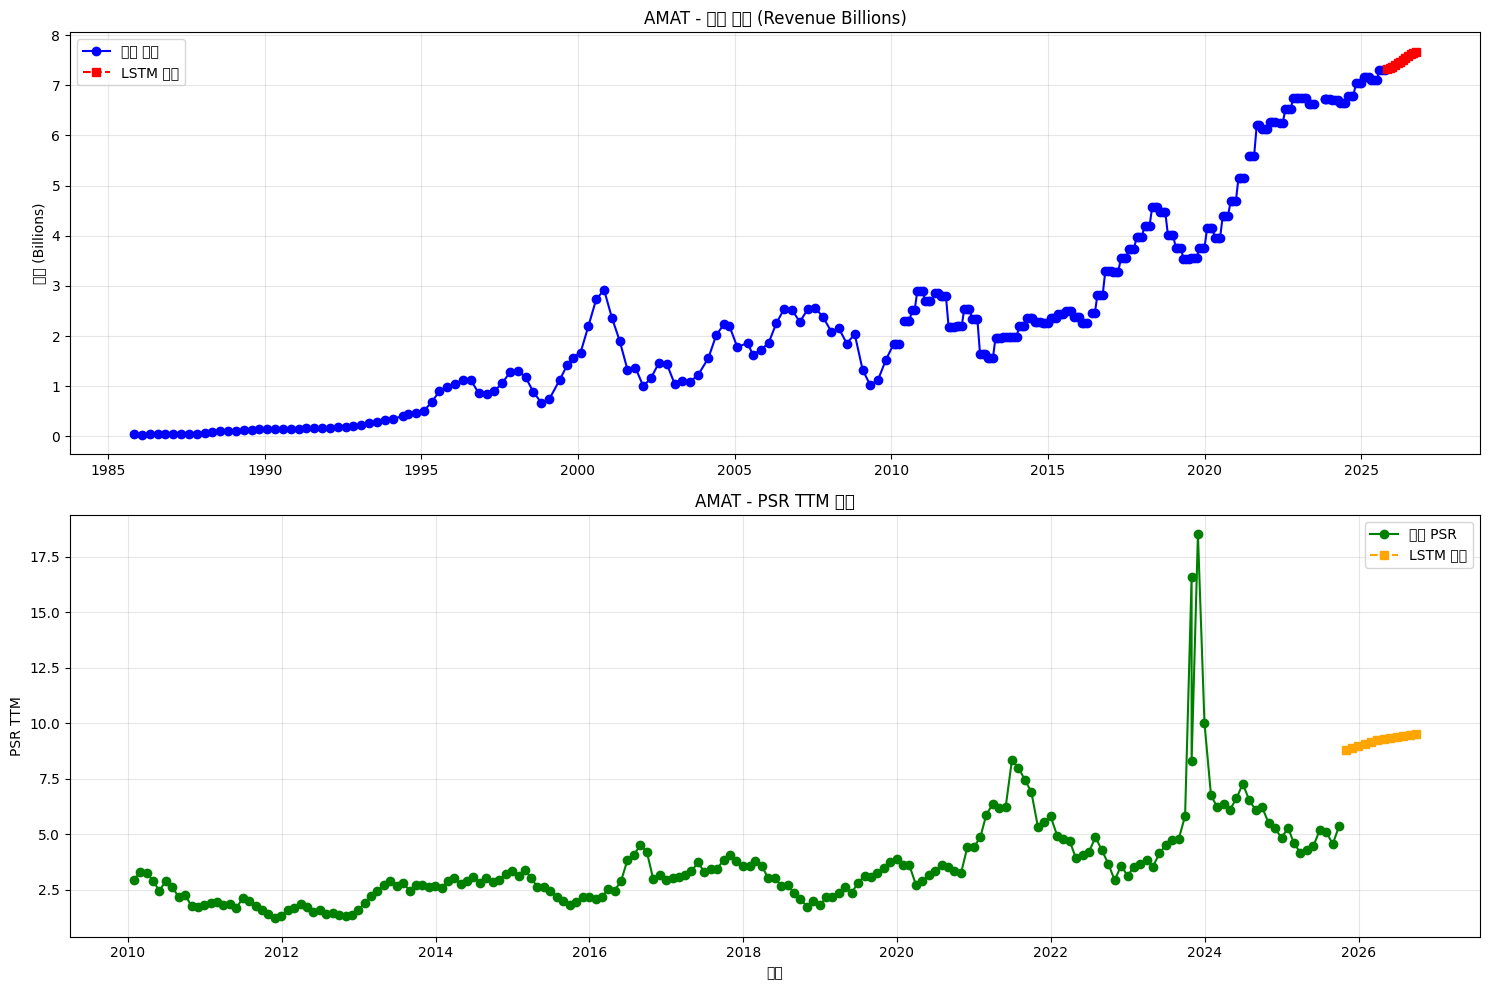

    date_month_end  revenue_billions   PSR_ttm
288     2025-10-31          7.325837  8.818059
290     2025-11-30          7.349755  8.906893
292     2025-12-31          7.370981  8.981133
294     2026-01-31          7.396697  9.055645
295     2026-02-28          7.439687  9.158688
298     2026-03-31          7.467423  9.232397
300     2026-04-30          7.509239  9.313206
302     2026-05-31          7.547895  9.354017
304     2026-06-30          7.588758  9.405592
305     2026-07-31          7.619968  9.429862
308     2026-08-31          7.644248  9.460282
310     2026-09-30          7.672535  9.508629


In [7]:
# 전처리된 데이터로 바로 예측
prediction_df, model_results = run_lstm_prediction(
    df=result,  # 앞서 전처리한 데이터
    ticker='AMAT',
    prediction_months=12,
    plot_results=True
)

# 예측 결과 확인
forecast_data = prediction_df[prediction_df['prediction_type'] == 'LSTM_forecast']
print(forecast_data[['date_month_end', 'revenue_billions', 'PSR_ttm']])

In [9]:
# ticker 포함해서 예측 수행
prediction_df, model_results = run_prophet_prediction(
    df=result,
    ticker='AMAT',  # 종목명 추가
    prediction_months=12
)

# 외생변수 미사용 예측 결과
no_exog_data = prediction_df[prediction_df['data_type'] == 'prophet_no_exog']

# 외생변수 사용 예측 결과
with_exog_data = prediction_df[prediction_df['data_type'] == 'prophet_with_exog']

# 예측 요약 정보
# summary = get_forecast_summary(model_results, ['revenue_billions', 'PSR_ttm'])

23:21:37 - cmdstanpy - INFO - Chain [1] start processing
23:21:37 - cmdstanpy - INFO - Chain [1] done processing
23:21:37 - cmdstanpy - INFO - Chain [1] start processing
23:21:37 - cmdstanpy - INFO - Chain [1] done processing
23:21:37 - cmdstanpy - INFO - Chain [1] start processing
23:21:37 - cmdstanpy - INFO - Chain [1] done processing
23:21:37 - cmdstanpy - INFO - Chain [1] start processing
23:21:37 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
prediction_df

,date_month_end,revenue_billions,PSR_ttm,data_type,ticker
0,1985-10-31,0.040000,NaN,actual,AMAT
1,1986-01-31,0.030000,NaN,actual,AMAT
2,1986-04-30,0.040000,NaN,actual,AMAT
3,1986-07-31,0.040000,NaN,actual,AMAT
4,1986-10-31,0.040000,NaN,actual,AMAT
...,...,...,...,...,...
342,2026-07-31,NaN,6.942385,prophet_with_exog,AMAT
343,2026-08-31,7.763274,NaN,prophet_with_exog,AMAT
344,2026-08-31,NaN,6.547392,prophet_with_exog,AMAT
345,2026-09-30,7.736073,NaN,prophet_with_exog,AMAT


In [ ]:
from us_ets_forecast import *

In [ ]:
prediction_df, model_results = run_ets_prediction(
    df=preprocessed_data,
    prediction_months=12
)

# 예측 결과 확인
ets_forecasts = prediction_df[prediction_df['data_type'] == 'ets_forecast']

# 선택된 모델 정보
model_info = model_results['model_selection']

# 예측 요약
summary = get_ets_forecast_summary(model_results, ['revenue_billions', 'PSR_ttm'])

# 백테스팅 (선택사항)
validation_results = validate_ets_models(preprocessed_data, test_periods=6)